# Feather Similarity Signals

Analyze sweep similarity curves saved under a runner results directory.

In [1]:
EXPERIMENT = "feather"
RUN_ID = None  # e.g. "feather_run_001"; None selects the newest run directory
METRICS_TO_PLOT = ["softmax_rwka", "rbf_rwka", "cka_rbf", "mutual_knn", "cknna"]
REF_LAYER = None
SAMPLE_PARAM = 1.0

In [2]:
import pathlib
import sys

start = pathlib.Path.cwd().resolve()
for candidate in [start, *start.parents]:
    if (candidate / "paths.py").exists():
        REPO_DIR = candidate
        break
else:
    raise RuntimeError("Could not find repo root containing paths.py")

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from paths import resources_path
from experiments.sweep_analysis import (
    add_experiment_preset_columns,
    entries_to_dataframe,
    list_sweep_metrics,
    load_sweep_entries,
    sample_similarity_at_param,
    save_preset_plots,
)

def latest_run(results_root):
    runs = [path for path in results_root.iterdir() if path.is_dir()]
    if not runs:
        raise FileNotFoundError(f"No run directories found under {results_root}")
    return max(runs, key=lambda path: path.stat().st_mtime)

results_root = resources_path / "results" / EXPERIMENT
results_path = results_root / RUN_ID if RUN_ID else latest_run(results_root)
sweeps_dir = results_path / "sweeps"
figures_dir = results_path / "figures" / "sweep_signals"
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Results path: {results_path}")
print(f"Sweeps path: {sweeps_dir}")
print(f"Figures path: {figures_dir}")

Results path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001
Sweeps path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/sweeps
Figures path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals


In [3]:
available_metrics = list_sweep_metrics(sweeps_dir)
metrics = [metric for metric in METRICS_TO_PLOT if metric in available_metrics]
if not metrics:
    metrics = available_metrics
print(f"Available sweep metrics: {available_metrics}")
print(f"Plotting metrics: {metrics}")

entries = load_sweep_entries(sweeps_dir)
sweep_df = entries_to_dataframe(entries)
sweep_df = add_experiment_preset_columns(sweep_df, EXPERIMENT, ref_layer=REF_LAYER)
print(sweep_df.shape)
print(sorted(sweep_df.columns))
sweep_df.head()

Available sweep metrics: ['cka_rbf', 'cknna', 'mutual_knn', 'rbf_rwka', 'softmax_rwka']
Plotting metrics: ['softmax_rwka', 'rbf_rwka', 'cka_rbf', 'mutual_knn', 'cknna']
(46321, 33)
['CKA', 'PWCCA', 'Procrustes', 'architecture1', 'architecture2', 'cka_rbf', 'cka_rbf_auc', 'cknna', 'cknna_auc', 'dataset1', 'dataset2', 'layer1', 'layer2', 'mean_cca_corr', 'mean_sq_cca_corr', 'metric', 'metric_auc', 'mutual_knn', 'mutual_knn_auc', 'param_name', 'param_values', 'path', 'rbf_rwka', 'rbf_rwka_auc', 'same_seed', 'scores', 'seed1', 'seed2', 'seed_mode', 'softmax_rwka', 'softmax_rwka_auc', 'step1', 'step2']


,path,metric,metric_auc,param_name,param_values,scores,dataset1,architecture1,seed1,step1,...,cka_rbf,cka_rbf_auc,cknna,cknna_auc,softmax_rwka,softmax_rwka_auc,rbf_rwka,rbf_rwka_auc,same_seed,seed_mode
0,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998695, 0.9999999999998695, 0.999...",mnli_matched_100,feather,0,0,...,2.996492e-13,4.249157e-12,NaN,NaN,NaN,NaN,NaN,NaN,True,same_seed
1,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998764, 0.9999999999998743, 0.999...",mnli_matched_100,feather,0,0,...,1.492678e-02,5.709664e-03,NaN,NaN,NaN,NaN,NaN,NaN,False,different_seed
2,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998769, 0.9999999999998747, 0.999...",mnli_matched_100,feather,0,0,...,1.513728e-02,5.797817e-03,NaN,NaN,NaN,NaN,NaN,NaN,False,different_seed
3,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998778, 0.9999999999998743, 0.999...",mnli_matched_100,feather,0,0,...,1.564754e-02,5.996760e-03,NaN,NaN,NaN,NaN,NaN,NaN,False,different_seed
4,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998773, 0.9999999999998739, 0.999...",mnli_matched_100,feather,0,0,...,1.483982e-02,5.674679e-03,NaN,NaN,NaN,NaN,NaN,NaN,False,different_seed


Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_softmax_rwka_seed_mode_by_layer.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_rbf_rwka_seed_mode_by_layer.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_cka_rbf_seed_mode_by_layer.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_mutual_knn_seed_mode_by_layer.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_cknna_seed_mode_by_layer.png


[PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_softmax_rwka_seed_mode_by_layer.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_rbf_rwka_seed_mode_by_layer.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_cka_rbf_seed_mode_by_layer.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_mutual_knn_seed_mode_by_layer.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/feather/feather_run_001/figures/sweep_signals/feather_cknna_seed_mode_by_layer.png')]

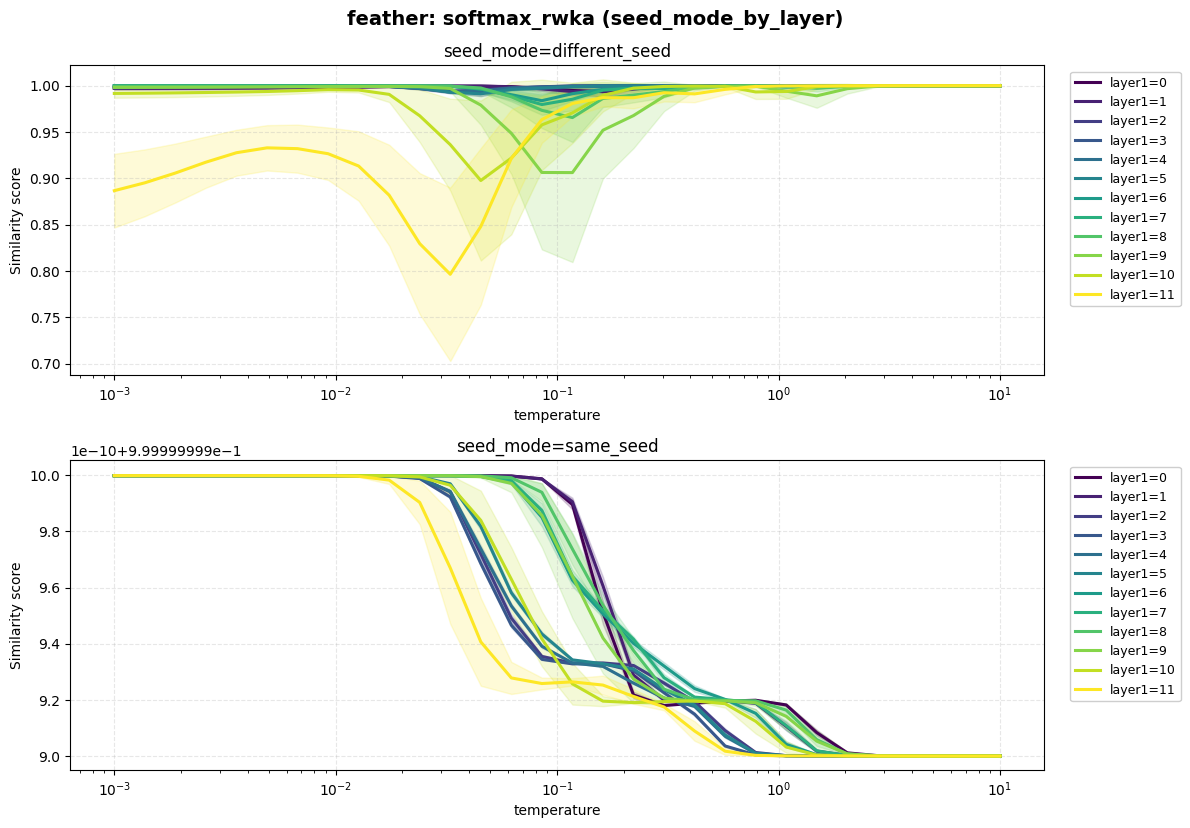

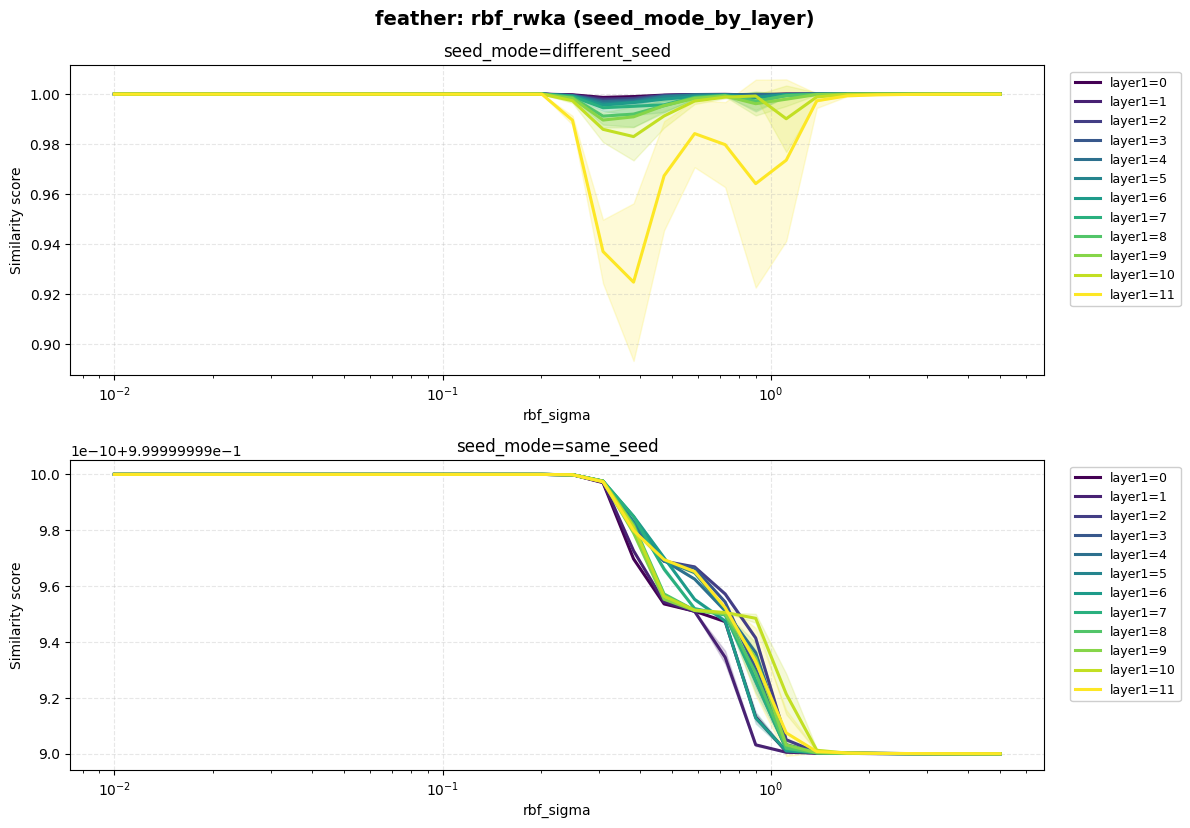

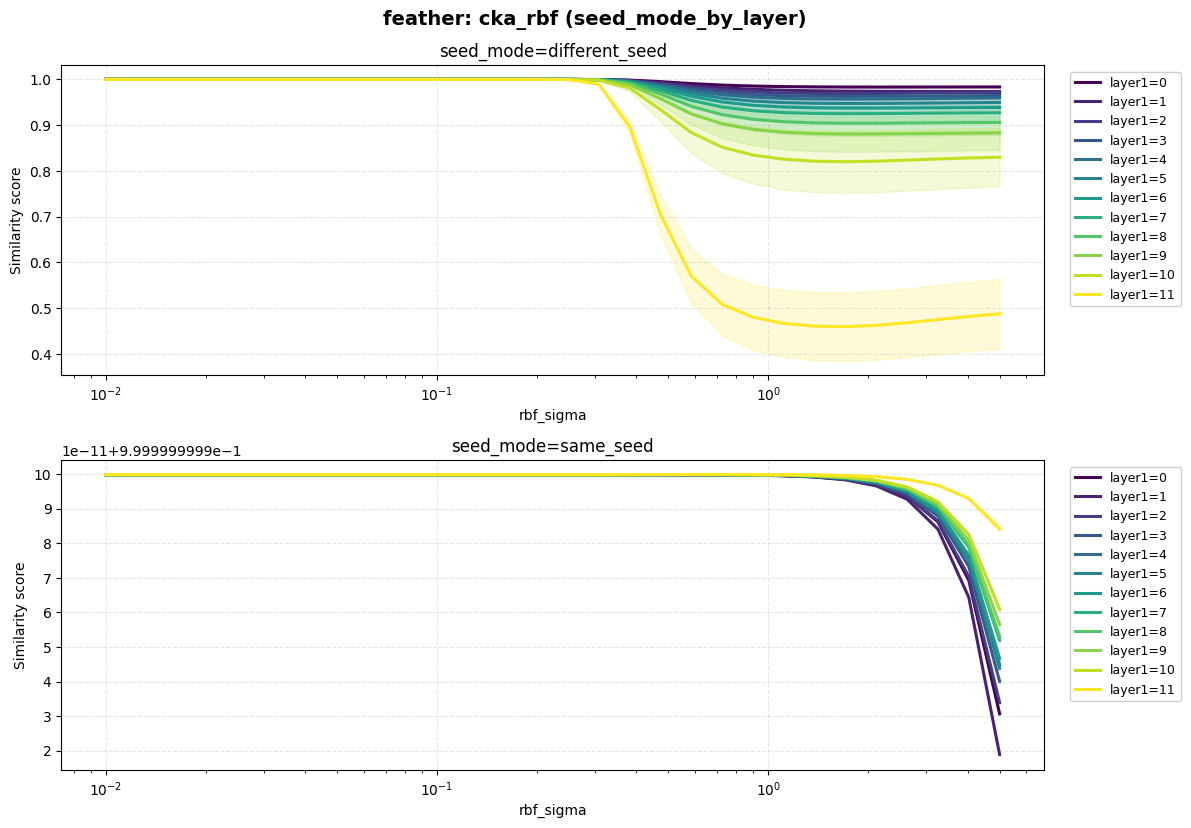

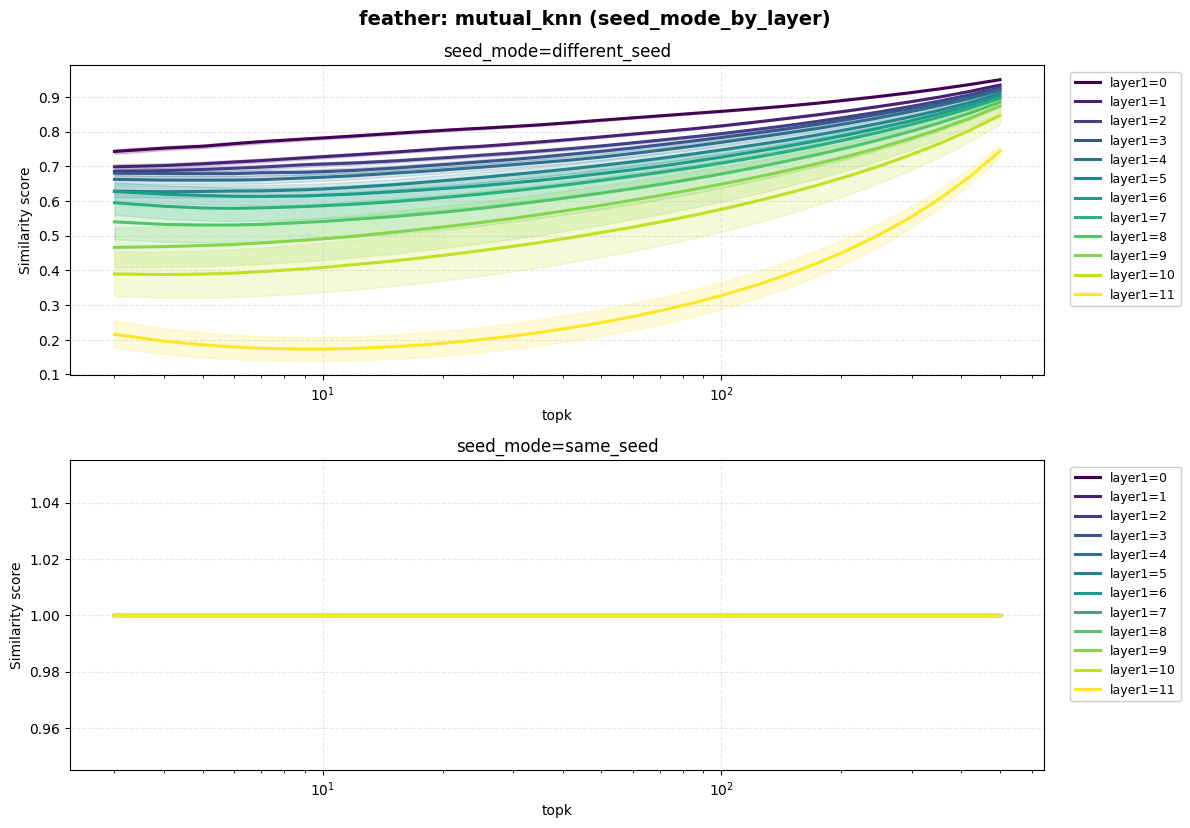

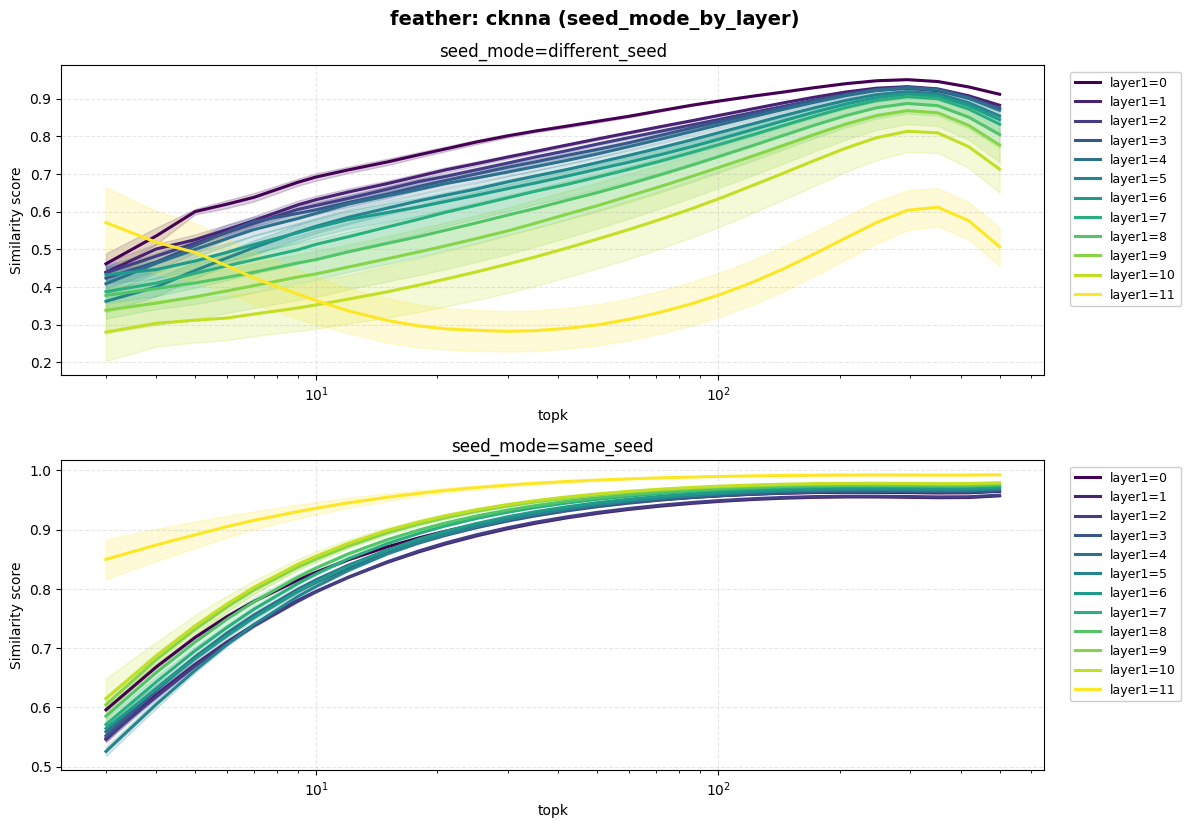

In [4]:
saved_paths = save_preset_plots(
    sweep_df,
    experiment=EXPERIMENT,
    metrics=metrics,
    figures_dir=figures_dir,
    ref_layer=REF_LAYER,
)
saved_paths

In [9]:
# Future heatmap scaffold: merge this sampled dataframe with full_df_self_computed.csv
# on representation metadata columns, then correlate similarity_at_param with task diffs.
sampled_df = sample_similarity_at_param(sweep_df, SAMPLE_PARAM, metric_name=metrics[0] if metrics else None)
sampled_df[["metric", "sampled_param", "similarity_at_param", "seed1", "seed2", "layer1"]].head()

,metric,sampled_param,similarity_at_param,seed1,seed2,layer1
37057,softmax_rwka,1.0,1.000000,0,0,0
37058,softmax_rwka,1.0,0.999958,0,10,0
37059,softmax_rwka,1.0,0.999901,0,11,0
37060,softmax_rwka,1.0,0.999901,0,12,0
37061,softmax_rwka,1.0,0.999918,0,13,0
